,dataset,n_files,mean,std,min,p25,median,p75,max
0,aishell7b,826,2.423729,1.452098,0.0,1.00,2.0,3.0,8.0
1,audiocap,800,2.430000,0.951367,1.0,2.00,2.0,3.0,5.0
2,clotho,800,1.570000,0.651997,1.0,1.00,1.0,2.0,3.0
3,musiccap,800,4.230000,2.092152,1.0,2.75,4.0,6.0,9.0
4,relate,874,2.517162,1.087816,1.0,2.00,2.0,3.0,7.0


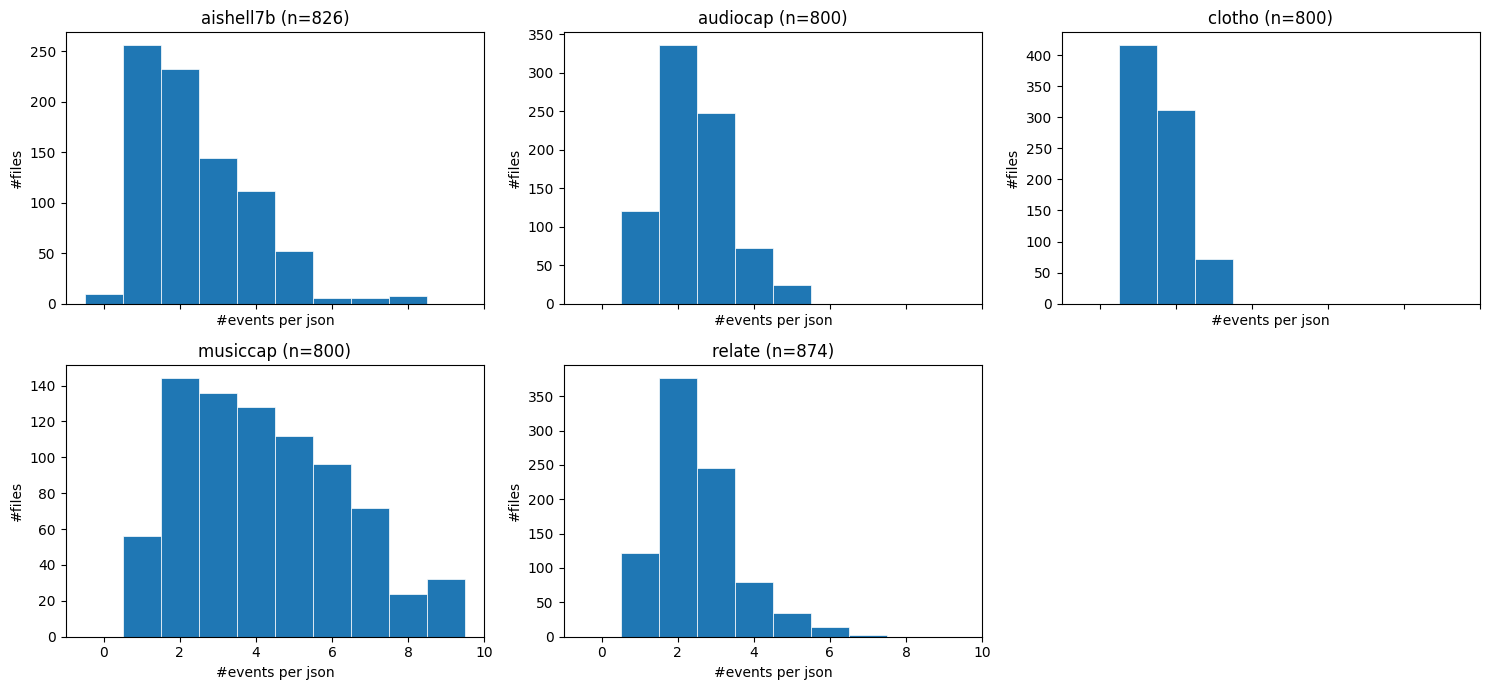

In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

base = Path("../") / "data" / "features" / "gpt_parsed_texts"
assert base.exists(), f"Not found: {base.resolve()}"

datasets = sorted([p for p in base.iterdir() if p.is_dir()])

# 1) JSONごとの event数（=文章数）をロング形式で保持
count_rows = []
error_rows = []

for ds_dir in datasets:
    json_files = sorted(ds_dir.rglob("*.json"))
    for fp in json_files:
        try:
            with open(fp, "r", encoding="utf-8") as f:
                obj = json.load(f)
            count_rows.append(
                {
                    "dataset": ds_dir.name,
                    "file": str(fp),
                    "n_events": int(len(obj)),
                }
            )
        except Exception as e:
            error_rows.append(
                {
                    "dataset": ds_dir.name,
                    "file": str(fp),
                    "error": repr(e),
                }
            )

counts_df = pd.DataFrame(count_rows)
errors_df = pd.DataFrame(error_rows)

if len(errors_df):
    display(errors_df.head(20))
    print(f"Errors: {len(errors_df)} (showing first 20)")

# 2) データセット別の統計（表）
rows = []
for ds, sub in counts_df.groupby("dataset"):
    arr = sub["n_events"].to_numpy(dtype=float)
    rows.append(
        {
            "dataset": ds,
            "n_files": int(len(arr)),
            "mean": float(np.mean(arr)) if len(arr) else np.nan,
            "std": float(np.std(arr)) if len(arr) else np.nan,
            "min": float(np.min(arr)) if len(arr) else np.nan,
            "p25": float(np.quantile(arr, 0.25)) if len(arr) else np.nan,
            "median": float(np.median(arr)) if len(arr) else np.nan,
            "p75": float(np.quantile(arr, 0.75)) if len(arr) else np.nan,
            "max": float(np.max(arr)) if len(arr) else np.nan,
        }
    )

stats_df = pd.DataFrame(rows).sort_values("dataset").reset_index(drop=True)
display(stats_df)

# 3) ヒストグラム（データセット別サブプロット）
# binsは全データ共通にして比較しやすくする
max_events = int(counts_df["n_events"].max()) if len(counts_df) else 0
bins = np.arange(0, max_events + 2) - 0.5  # 整数中心のビン

n_ds = len(stats_df)
cols = 3
rows_n = int(np.ceil(n_ds / cols)) if n_ds else 1

fig, axes = plt.subplots(
    rows_n, cols, figsize=(cols * 5, rows_n * 3.5), sharex=True, sharey=False
)
axes = np.array(axes).reshape(-1)

for ax in axes[n_ds:]:
    ax.axis("off")

for i, ds in enumerate(stats_df["dataset"].tolist()):
    ax = axes[i]
    sub = counts_df[counts_df["dataset"] == ds]["n_events"].to_numpy()
    ax.hist(sub, bins=bins, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{ds} (n={len(sub)})")
    ax.set_xlabel("#events per json")
    ax.set_ylabel("#files")

plt.tight_layout()
plt.show()
